#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [2]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [4]:
# Import Eda Libraries
os.chdir(scripts_path)
from exploration import coeff_var_skew, num_uni_hist_box
from ml_eda import confusion_matrix_display, classification_report_display, roc_curve_display, decision_tree_display

In [5]:
# Import Advanced Libraries
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, classification_report, roc_curve, auc

In [6]:
# Load & Copy Dataset
os.chdir(data_exploration_path)
original_df = pd.read_csv("eda_processed_data.csv")
df = original_df.copy()

In [7]:
# First Column Drop
df.drop(columns='Unnamed: 0',inplace=True)

In [8]:
# Dataset Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,IsWeekend,Regions,Topic Group
593,82.07,24,50337.93,193.97,0,0,1,6,0,Asia,1
453,83.42,25,49850.52,183.42,1,0,4,3,0,Europe,5
147,70.92,41,49995.63,108.16,1,1,3,5,0,Europe,1


#### B. FEATURE ENGINEERING

In [10]:
# Missing Value Check
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
Day                         0
Month                       0
IsWeekend                   0
Regions                     0
Topic Group                 0
dtype: int64

In [11]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [12]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [13]:
# Convert Booleans
df_processed = df_encoded.astype(int).copy()

#### C. ADABOOST: ML ENGINEERING

In [15]:
# Define Columns: 
selected_col = ['Daily Internet Usage', 'Daily Time Spent on Site',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [16]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [17]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
# Load Model
abc = AdaBoostClassifier()

In [19]:
# Param Grid
param_grid = {
    'n_estimators': np.arange(64, 201, 45),  # Number of weak learners
    'learning_rate': np.logspace(-2, 0, 5),  # Controls contribution of each weak learner
    'algorithm': ['SAMME']  # SAMME for discrete, SAMME.R for real AdaBoost
}

In [20]:
# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(abc, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'algorithm': ['SAMME'],
                         'learning_rate': array([0.01      , 0.03162278, 0.1       , 0.31622777, 1.        ]),
                         'n_estimators': array([ 64, 109, 154, 199])},
             scoring='accuracy', verbose=1)

In [21]:
# Best Model
best_model = grid_search.best_estimator_

In [22]:
# Print Best Parameters and best score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Accuracy: 0.9573 ± 0.0161


In [23]:
# Best Model
best_model = grid_search.best_estimator_

In [24]:
# Prediction
y_pred = best_model.predict(X_test)

In [25]:
# Predict Probabililty
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

In [26]:
# Classification Report
classification_report_display(y_test,y_pred)

Classification Report:
----------------------------------------
              precision    recall  f1-score  support
0              0.925620  0.933333  0.929461  120.000
1              0.937984  0.930769  0.934363  130.000
accuracy       0.932000  0.932000  0.932000    0.932
macro avg      0.931802  0.932051  0.931912  250.000
weighted avg   0.932049  0.932000  0.932010  250.000


In [27]:
# Confussion Matrix
confusion_matrix_display(y_test, y_pred, labels=['Class 0', 'Class 1'])

Confusion Matrix:
----------------------------------------
                Predicted Class 0  Predicted Class 1
Actual Class 0                112                  8
Actual Class 1                  9                121


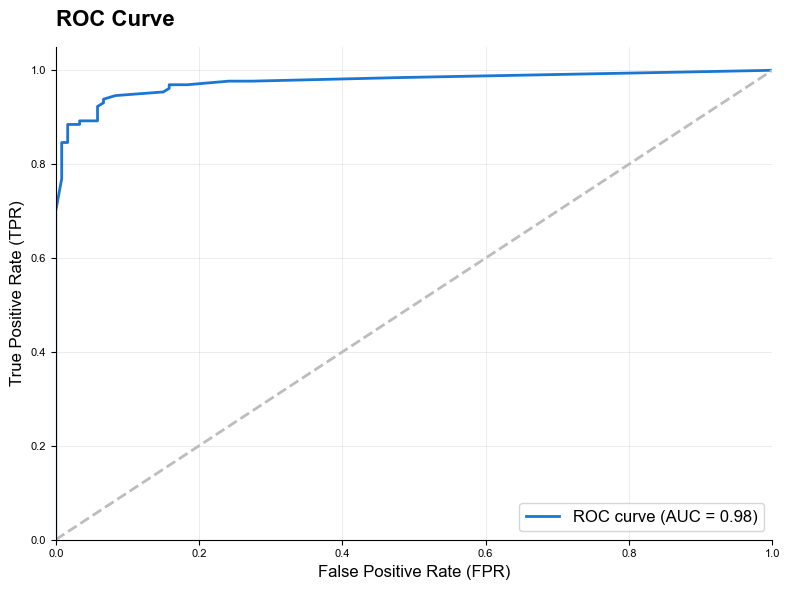

In [28]:
# ROC & AUC Curve
roc_curve_display(y_test, y_pred_prob, plot_title="ROC Curve")

In [29]:
# Feature Importance
pd.DataFrame(index=X.columns, data=best_model.feature_importances_, columns=['Feature Importance']).sort_values('Feature Importance',ascending=False)

,Feature Importance
Daily Internet Usage,0.557333
Daily Time Spent on Site,0.442667


In [30]:
# Shape Explainer
explainer = shap.TreeExplainer(best_model.estimators_[0]) 

In [31]:
# Shap Values
shap_values = explainer.shap_values(X_test)

In [32]:
shap_values_class_1 = shap_values[:, :, 1]

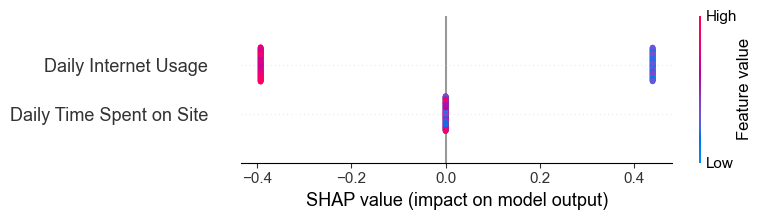

In [33]:
# Visualize SHAP Summary Plot (Class 1)
shap.summary_plot(shap_values_class_1, X_test, feature_names=X.columns.tolist())

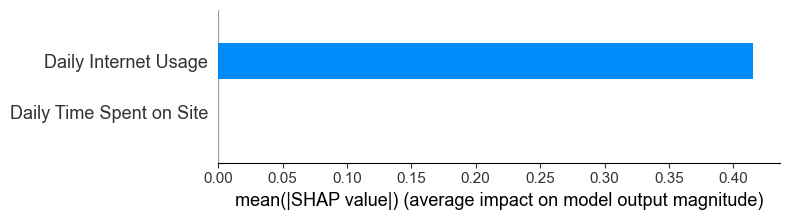

In [34]:
# Visualize SHAP Summary Plot in Bar Format (Class 1)
shap.summary_plot(shap_values_class_1, X_test, feature_names=X.columns.tolist(), plot_type="bar")

#### D. ADABOOST: FINAL MODEL

In [36]:
# Define Columns
selected_col = ['Daily Internet Usage',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [37]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [38]:
# Final Model Load
final_model = AdaBoostClassifier(algorithm='SAMME', learning_rate=0.31622776601683794,
                   n_estimators=109)

In [39]:
# Final Model Fit
final_model.fit(X, y)

AdaBoostClassifier(algorithm='SAMME', learning_rate=0.31622776601683794,
                   n_estimators=109)

In [40]:
# New Values
Daily_Internet_Usage = 0

data = {
    'Daily Internet Usage': [Daily_Internet_Usage],
}

new_pred = pd.DataFrame(data)
new_pred

,Daily Internet Usage
0,0


In [41]:
# Predict Probabililty of Clicking
prob_class_0 = round(float(final_model.predict_proba(new_pred)[0][0]*100),2)
prob_class_1 = round(float(final_model.predict_proba(new_pred)[0][1]*100),2)
print(f"\033[1m- Probability of Class 0:\033[0m {prob_class_0}%")
print(f"\033[1m- Probability of Class 1:\033[0m {prob_class_1}%")

- Probability of Class 0: 11.92%
- Probability of Class 1: 88.08%
